### Workbook for further processing needs assessment data and extracting Worldpop population estimates
Week of May 12, 2025
Author: Adele Birkenes

In [13]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import rasterio
from rasterio.mask import mask
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Task 1: Set synced & unsynced file paths, read in needs assessment data & Worldpop raster, ensure CRSs match

In [14]:
synced_path = "../../synced-data/population-exploration/"
unsynced_path = "../../unsynced-data"

# Specify file path for needs assessment data
needs_assessment_fp = os.path.join(unsynced_path, "processed_needs_assessments_05_11.geojson") #update if needed

# Import original village boundaries so that the correct CRS can be set
village_boundaries_fp = os.path.join(synced_path, "Rwanda Village Boundaries/Village.shp")
village_boundaries = gpd.read_file(village_boundaries_fp)

# Read the needs assessment data into a geodataframe and print the CRS
needs_assessment = gpd.read_file(needs_assessment_fp)

In [15]:
# Specify file path for Worldpop raster
worldpop_fp = os.path.join(unsynced_path, "WorldPop_Rasters_2020.nosync/rwa_ppp_2020_UNadj_constrained.tif")

# Print CRS of raster
with rasterio.open(worldpop_fp) as src:
    print(src.crs)
    print(src.res)

EPSG:4326
(0.0008333333302002449, 0.0008333333299256504)


In [16]:
# Print CRS of needs assessment data
print("Needs assessment CRS:", needs_assessment.crs)
print("Needs assessment bounds:", needs_assessment.total_bounds)

# # Force needs_assessment to use the same CRS as village boundaries
# # (this fixes the CRS label without moving coordinates)
# needs_assessment = needs_assessment.set_crs(village_boundaries.crs, allow_override=True)

# # Reproject needs_assessment to match raster CRS (EPSG:4326)
# with rasterio.open(worldpop_fp) as src:
#     needs_assessment = needs_assessment.to_crs(src.crs)

# # Sanity check
# print("Needs assessment CRS after reprojection:", needs_assessment.crs)
# print("Needs assessment bounds after reprojection:", needs_assessment.total_bounds)

Needs assessment CRS: EPSG:4326
Needs assessment bounds: [28.89096975 -2.81623842 30.85291996 -1.32732663]


In [17]:
print("Needs assessment CRS:", needs_assessment.crs)
print("Needs assessment bounds:", needs_assessment.total_bounds)

with rasterio.open(worldpop_fp) as src:
    print("Raster CRS:", src.crs)
    print("Raster bounds:", src.bounds)

Needs assessment CRS: EPSG:4326
Needs assessment bounds: [28.89096975 -2.81623842 30.85291996 -1.32732663]
Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=28.857083233, bottom=-2.838749787, right=30.896249892, top=-1.045416461)


Task 2: Conduct light cleaning of needs assessment data: remove communities with likely data entry errors (population counts of 0 or 1). Count number of repeated communities with & without conflicting population counts.

In [18]:
# Get stats on likely number of data entry errors (0 or 1 in Individuals Served column)
print("Prior to data cleaning:")
print(f'Number of communities with 0 individuals served: {needs_assessment["Individuals Served"].value_counts().get(0, 0)}')
print(f'Number of communities with 1 individuals served: {needs_assessment["Individuals Served"].value_counts().get(1, 0)}')

# Remove any rows with a count of 0 or 1 in the Individuals Served column
needs_assessment = needs_assessment[~needs_assessment["Individuals Served"].isin([0, 1])]

Prior to data cleaning:
Number of communities with 0 individuals served: 57
Number of communities with 1 individuals served: 8


In [19]:
# Get stats on number of repeated communities (same admin 2, 3, and 5 values)
repeated_communities_count = needs_assessment.groupby(['Admin 5', 'Admin 3', 'Admin 2']).size().reset_index(name='Count')
repeated_communities = repeated_communities_count[repeated_communities_count['Count'] > 1]
print("After data cleaning:")
print(f'Number of repeated communities: {len(repeated_communities)}')

# Count the number of communities with conflicting population counts
grouped = needs_assessment.groupby(['Admin 5', 'Admin 3', 'Admin 2'])
conflicting_groups = grouped['Individuals Served'].nunique().reset_index()
conflicting_groups = conflicting_groups[conflicting_groups['Individuals Served'] > 1]
print(f'Number of communities with conflicting population counts: {conflicting_groups.shape[0]}')

After data cleaning:
Number of repeated communities: 505
Number of communities with conflicting population counts: 237


In [20]:
# Print years of needs assessments by extracting the year from "Form: Form Name"
# This field is structured "Project Assessment - YYYY.MM.DD", for example
# Order in chronological order by year
needs_assessment['Year'] = needs_assessment['Form: Form Name'].str.extract(r'(\d{4})')
print("Years of needs assessments:")
print(needs_assessment['Year'].value_counts().sort_index())

# Calculate percent of needs assessments that took place in 2018
percent_2018 = (needs_assessment['Year'] == '2018').mean() * 100
print(f'Percent of needs assessments that took place in 2018: {percent_2018:.2f}%')

Years of needs assessments:
Year
2017       2
2018    2050
2019      14
2020       4
2021       1
2022      48
2023     177
2024     124
2025      92
Name: count, dtype: int64
Percent of needs assessments that took place in 2018: 81.61%


Task 3: Extract Worldpop population estimates for communities in needs assessment gdf

In [21]:
# Use extract-pop function (from pop-estimates.ipynb) to extract population estimates from Worldpop
# Note: In order to run successfully, both the needs assessment gdf and the Worldpop raster must be in the same CRS
# In this case, as confirmed above, both are in WGS84 (EPSG:4326)

def extract_pop(pop_raster, population_raster_name, villages_near_bridges):
    
    # Copy input geodataframe to avoid modifying the original
    villages_copy = villages_near_bridges.copy()
    
    with rasterio.open(pop_raster) as src:
        # Print information from raster profile
        print("CRS:", src.crs)
        print("Raster shape:", src.shape)
        print("Number of Bands:", src.count)

        # Iterate over each village and extract population data
        results = []
        for idx, row in villages_copy.iterrows():
            try:
                out_image = mask(src, [row.geometry], crop=True)
                out_image = out_image[0]

                # Handle masked arrays and replace with 0
                if np.ma.is_masked(out_image):
                    out_image = out_image.filled(0)

                # Remove negative values (e.g., nodata placeholders)
                out_image = np.where(out_image < 0, 0, out_image)

                total_population = np.sum(out_image)

            except Exception as e:
                print(f"Error at village {idx}: {e}")
                total_population = 0  # or np.nan

            results.append(total_population)

        # Add population data to the gdf
        villages_copy[population_raster_name] = results

    return villages_copy

needs_assessment_worldpop = extract_pop(pop_raster=worldpop_fp, 
                                 population_raster_name="WorldPop_2020",
                                 villages_near_bridges=needs_assessment)

needs_assessment_worldpop.head()
#needs_assessment_worldpop.explore()

CRS: EPSG:4326
Raster shape: (2152, 2447)
Number of Bands: 1


,Admin 2,Village_ID,Cell_ID,Sector_ID,Distr_ID,Prov_ID,Admin 5,Admin 4_x,Admin 3,Admin 1_x,...,Bridge Opportunity: Population Estimate 2000m,Row ID,Community Column,Community Number,Bridge Opportunity: CaseSafeID_y,Individuals Served Column,Individuals Served,geometry,Year,WorldPop_2020
0,Nyarugenge,11010103,110101,1101,11,1,Iterambere,Akabahizi,Gitega,Kigali Town/Umujyi wa Kigali,...,172079.0,1257.0,Community Served 1,1,006f100000eekXgAAI,Individuals served in Community 1,510.0,"POLYGON Z ((30.05147 -1.94394 0, 30.05169 -1.9...",2018,1214.437744
1,Nyarugenge,11010106,110101,1101,11,1,Nyenyeri,Akabahizi,Gitega,Kigali Town/Umujyi wa Kigali,...,172079.0,1257.0,Community Served 2,2,006f100000eekXgAAI,Individuals served in Community 2,652.0,"POLYGON Z ((30.05195 -1.94681 0, 30.05203 -1.9...",2018,549.301880
2,Nyarugenge,11010107,110101,1101,11,1,Ubukorikori,Akabahizi,Gitega,Kigali Town/Umujyi wa Kigali,...,190281.0,1253.0,Community Served 2,2,006f100000eekXCAAY,Individuals served in Community 2,523.0,"POLYGON Z ((30.05488 -1.94678 0, 30.05496 -1.9...",2018,1542.030273
3,Nyarugenge,11010108,110101,1101,11,1,Ubumwe,Akabahizi,Gitega,Kigali Town/Umujyi wa Kigali,...,193056.0,1250.0,Community Served 2,2,006f100000eekWsAAI,Individuals served in Community 2,523.0,"POLYGON Z ((30.04829 -1.94176 0, 30.04833 -1.9...",2018,982.368225
4,Nyarugenge,11010108,110101,1101,11,1,Ubumwe,Akabahizi,Gitega,Kigali Town/Umujyi wa Kigali,...,207606.0,1252.0,Community Served 2,2,006f100000eekX7AAI,Individuals served in Community 2,524.0,"POLYGON Z ((30.04829 -1.94176 0, 30.04833 -1.9...",2018,982.368225


Task 4: Calculate statistics comparing needs assessment population counts to Worldpop population estimates

In [22]:
# Create column to store difference between needs assessment and Worldpop counts
# Difference = Needs assessment count - Worldpop count
needs_assessment_worldpop["Difference"] = needs_assessment_worldpop["Individuals Served"] - needs_assessment_worldpop["WorldPop_2020"]

# Calculate mean and median of the difference
mean_difference = needs_assessment_worldpop["Difference"].mean()
print(f"Mean difference: {mean_difference}")
median_difference = needs_assessment_worldpop["Difference"].median()
print(f"Median difference: {median_difference}")

# Calculate standard deviation of the absolute difference
std_dev_abs_difference = needs_assessment_worldpop["Difference"].abs().std()
print(f"Standard deviation of absolute difference: {std_dev_abs_difference}")

Mean difference: 13.92774084267343
Median difference: 15.4130859375
Standard deviation of absolute difference: 978.4947242496937


In [23]:
# Calculate number of communities with roughly matching population counts
print(f"Number of communities with roughly matching population counts: {(abs(needs_assessment_worldpop["Difference"]) < 100).sum()}")

# Calculate number of undercounted communities (Worldpop count > Needs assessment count)
print(f"Number of undercounted communities: {(needs_assessment_worldpop["Difference"] < 0).sum()}")

# Calculate number of overcounted communities (Needs assessment count > Worldpop count)
print(f"Number of overcounted communities: {(needs_assessment_worldpop["Difference"] > 0).sum()}")


Number of communities with roughly matching population counts: 747
Number of undercounted communities: 1191
Number of overcounted communities: 1321


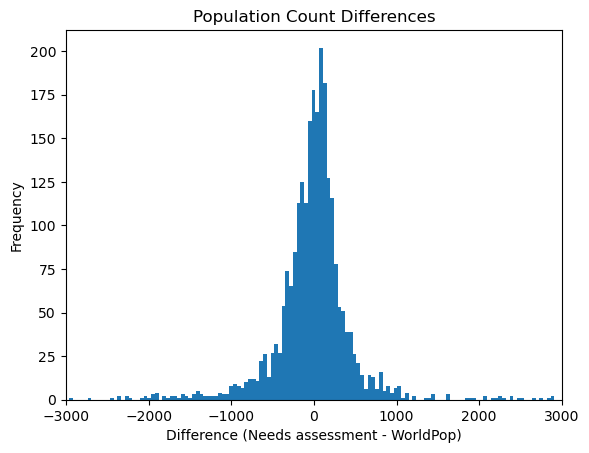

In [24]:
# Create histogram of difference
plt.hist(needs_assessment_worldpop["Difference"], bins=1000)
# Set x axis limits
plt.xlim(-3000, 3000)
# Set x and y axis labels
plt.xlabel("Difference (Needs assessment - WorldPop)")
plt.ylabel("Frequency")
# Set title
plt.title("Population Count Differences")
# Show plot
plt.show()

In [25]:
from scipy.stats import norm, gaussian_kde

def plot_difference_histogram(df, diff_col, use_density=True, bins=200):

    diffs = df[diff_col].dropna()

    plt.figure(figsize=(8,5))

    # Histogram
    counts, bin_edges, _ = plt.hist(
        diffs,
        bins=bins,
        density=use_density,
        alpha=0.5,
        label="_Histogram_"
    )

    # X grid
    x = np.linspace(min(diffs), max(diffs), 500)

    # --- Actual distribution (KDE) ---
    kde = gaussian_kde(diffs)

    if use_density:
        kde_y = kde(x)
    else:
        # scale KDE to match histogram counts
        bin_width = bin_edges[1] - bin_edges[0]
        kde_y = kde(x) * len(diffs) * bin_width

    plt.plot(x, kde_y, linewidth=2, label="Actual distribution (KDE)")

    # --- Normal distribution ---
    mu, sigma = norm.fit(diffs)

    if use_density:
        normal_y = norm.pdf(x, mu, sigma)
    else:
        bin_width = bin_edges[1] - bin_edges[0]
        normal_y = norm.pdf(x, mu, sigma) * len(diffs) * bin_width

    plt.plot(x, normal_y, linewidth=2, linestyle="--",
             label="Normal distribution")

    # --- Median line ---
    median_val = np.median(diffs)
    plt.axvline(median_val, linestyle=":", linewidth=2, color="black",
                label=f"Median = {median_val:.1f}")

    # --- Zero line ---
    # plt.axvline(0, linestyle="-.", linewidth=2,
    #             label="Zero difference")

    # Labels
    plt.xlabel("Population difference (Needs assessment − WorldPop)")
    plt.ylabel("Density" if use_density else "Number of villages")
    plt.xlim(-3000, 3000)

    plt.legend()
    plt.tight_layout()
    plt.show()

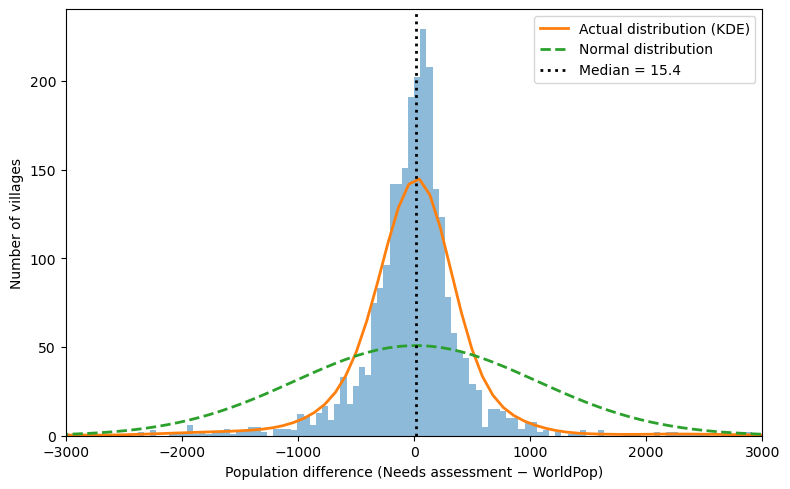

In [26]:
plot_difference_histogram(
    df=needs_assessment_worldpop, 
    diff_col="Difference", 
    use_density=False, 
    bins="auto"
)

In [33]:
from scipy.stats import wilcoxon

def test_worldpop_accuracy(df, needs_col, worldpop_col):

    data = df[[needs_col, worldpop_col]].dropna().copy()
    diff = data[needs_col] - data[worldpop_col]

    stat, p = wilcoxon(diff, alternative='two-sided')

    median_pop = np.median(data[needs_col])
    mean_pop   = np.mean(data[needs_col])

    print("WorldPop vs Needs Assessment")
    print("--------------------------------")
    print(f"N villages: {len(data)}")
    print(f"Median village population: {median_pop:.1f}")

    print(f"Median difference: {np.median(diff):.1f} "
          f"({np.median(diff)/median_pop*100:.1f}% of median village population)")

    print(f"Mean difference: {np.mean(diff):.1f} "
          f"({np.mean(diff)/mean_pop*100:.1f}% of mean village population)")

    print(f"Median absolute error: {np.median(np.abs(diff)):.1f}")

    print(f"Wilcoxon statistic: {stat}")
    print(f"p-value: {p:.6f}")

    if p < 0.05:
        print("→ Significant difference detected.")
    else:
        print("→ No significant difference detected.")

    return stat, p

In [34]:
test_worldpop_accuracy(df=needs_assessment_worldpop, needs_col="Individuals Served", worldpop_col="WorldPop_2020")

WorldPop vs Needs Assessment
--------------------------------
N villages: 2512
Median village population: 719.0
Median difference: 15.4 (2.1% of median village population)
Mean difference: 13.9 (1.6% of mean village population)
Median absolute error: 178.0
Wilcoxon statistic: 1559602.0
p-value: 0.609651
→ No significant difference detected.


(np.float64(1559602.0), np.float64(0.6096513487430009))

In [29]:
needs_assessment_worldpop["abs_error"] = abs(needs_assessment_worldpop["Individuals Served"] - needs_assessment_worldpop["WorldPop_2020"])
needs_assessment_worldpop["pct_error"] = 100 * needs_assessment_worldpop["abs_error"] / needs_assessment_worldpop["Individuals Served"]

print("Absolute error:", needs_assessment_worldpop["abs_error"].median())
print("Percentage error:", needs_assessment_worldpop["pct_error"].median())
print(needs_assessment_worldpop[["Individuals Served","WorldPop_2020"]].corr())

Absolute error: 178.04986572265625
Percentage error: 25.53151797015863
                    Individuals Served  WorldPop_2020
Individuals Served            1.000000       0.190893
WorldPop_2020                 0.190893       1.000000


In [51]:
def plot_worldpop_scatter(df, needs_col, worldpop_col):

    x = df[needs_col]
    y = df[worldpop_col]

    plt.figure(figsize=(7,7))
    plt.scatter(x, y, alpha=0.3, s=15)

    # 1:1 line
    lims = [
        np.min([x.min(), y.min()]),
        np.max([x.max(), y.max()])
    ]
    plt.plot(lims, lims, 'k--', linewidth=2)

    plt.xlabel("Needs Assessment Population")
    plt.ylabel("WorldPop Population Estimate")
    plt.title("Village Population: WorldPop vs Needs Assessment")

    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

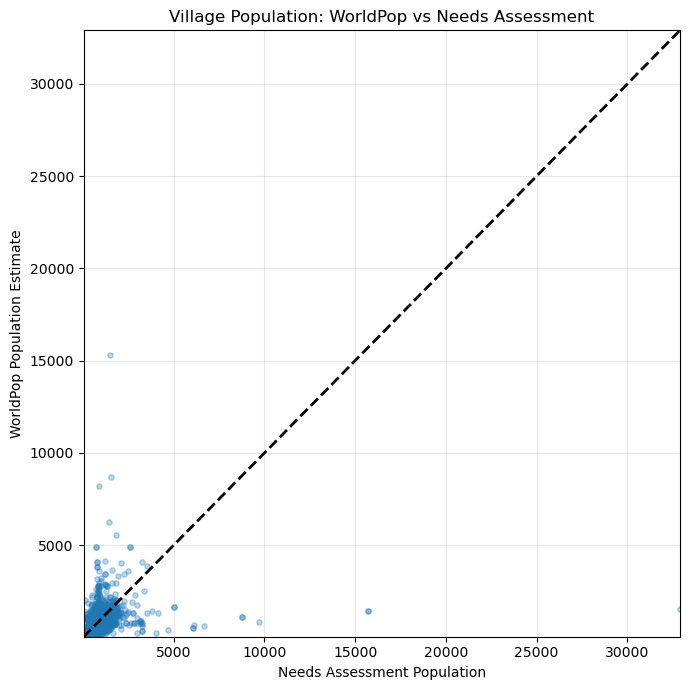

In [52]:
plot_worldpop_scatter(df=needs_assessment_worldpop, 
                      needs_col="Individuals Served", 
                      worldpop_col="WorldPop_2020")

In [53]:
def plot_bland_altman(df, needs_col, worldpop_col):

    needs = df[needs_col]
    worldpop = df[worldpop_col]

    mean_vals = (needs + worldpop) / 2
    diff_vals = worldpop - needs

    mean_diff = np.mean(diff_vals)
    std_diff = np.std(diff_vals)

    plt.figure(figsize=(7,6))
    plt.scatter(mean_vals, diff_vals, alpha=0.3, s=15)

    # Mean difference line
    plt.axhline(mean_diff, linestyle='--', linewidth=2)

    # Limits of agreement
    plt.axhline(mean_diff + 1.96*std_diff, linestyle=':', linewidth=2)
    plt.axhline(mean_diff - 1.96*std_diff, linestyle=':', linewidth=2)

    plt.xlabel("Mean Village Population")
    plt.ylabel("WorldPop − Needs Assessment")
    plt.title("Bland–Altman Plot: WorldPop vs Needs Assessment")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

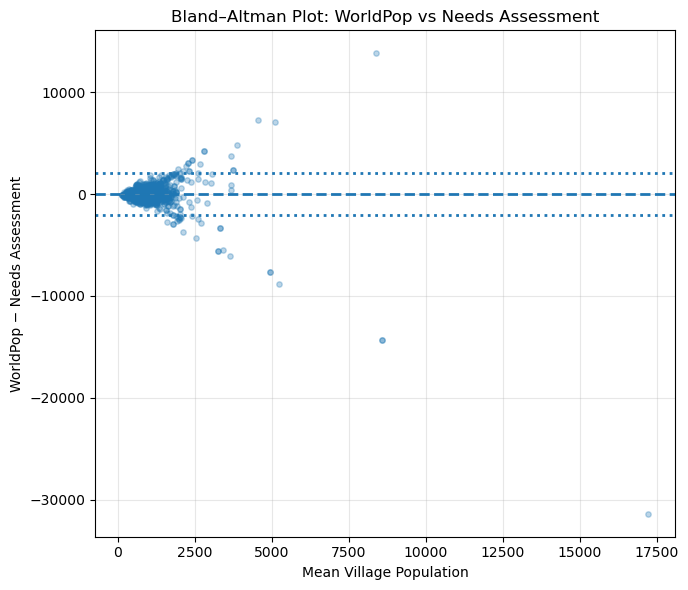

In [54]:
plot_bland_altman(df=needs_assessment_worldpop, 
                  needs_col="Individuals Served", 
                  worldpop_col="WorldPop_2020")

In [10]:
# Create boxplot of difference
#plt.boxplot(needs_assessment_worldpop["Difference"])
#plt.show()

In [12]:
# Export needs-assessment-worldpop gdf as geojson
#needs_assessment_worldpop.to_file(os.path.join(unsynced_path, "needs_assessment_worldpop_05_11.geojson"), driver="GeoJSON")

# Export needs-assessment-worldpop gdf as shapefile
#needs_assessment_worldpop.to_file(os.path.join(unsynced_path, "needs_assessment_worldpop_05_11.shp"), driver="ESRI Shapefile")